170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Training data: (50000, 32, 32, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 46ms/step - accuracy: 0.4525 - loss: 1.4956 - val_accuracy: 0.5436 - val_loss: 1.2553
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.5992 - loss: 1.1361 - val_accuracy: 0.6296 - val_loss: 1.0385
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.6569 - loss: 0.9771 - val_accuracy: 0.6573 - val_loss: 0.9764
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - accuracy: 0.6965 - loss: 0.8701 - val_accuracy: 0.6840 - val_loss: 0.9051
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.7223 - loss: 0.7906 - val_accuracy: 0.6870 - val_loss: 0.9092
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.7470 - loss: 0.7200 - val_accuracy: 0.6999 - val_loss: 0.8851
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 44ms/step - accuracy: 0.7663 - loss: 0.6633 - val_accuracy: 0.6989 - val_loss: 0.9003
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 44ms/step - accuracy: 0.7876 -

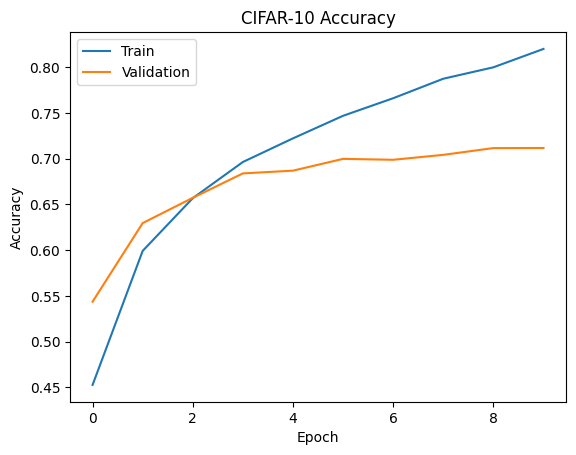

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step


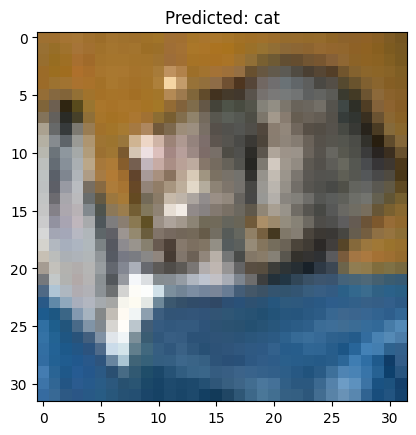

In [1]:
# CASE STUDY 2 : CIFAR-10 Image Classification

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

# 1 Load Dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print("Training data:", x_train.shape)

# 2 Normalize Images
x_train = x_train / 255.0
x_test = x_test / 255.0

# 3 Class Labels
class_names = [
'airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck'
]

# 4 Build CNN Model
model = keras.Sequential([

layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
layers.MaxPooling2D((2,2)),

layers.Conv2D(64,(3,3),activation='relu'),
layers.MaxPooling2D((2,2)),

layers.Conv2D(64,(3,3),activation='relu'),

layers.Flatten(),

layers.Dense(128,activation='relu'),
layers.Dense(10,activation='softmax')

])

# 5 Compile Model
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

# 6 Train Model
history = model.fit(
x_train,
y_train,
epochs=10,
validation_data=(x_test,y_test)
)

# 7 Evaluate
loss, accuracy = model.evaluate(x_test,y_test)
print("Test Accuracy:", accuracy)

# 8 Plot Accuracy Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("CIFAR-10 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

# 9 Prediction Example
predictions = model.predict(x_test)

plt.imshow(x_test[0])
plt.title("Predicted: " + class_names[np.argmax(predictions[0])])
plt.show()